# Unveiling the Android App Market: Analyzing Google Play Store Data

## Objective
This project analyzes the Google Play Store dataset to understand app market dynamics — category distribution, ratings, pricing, and user sentiment — to derive actionable business insights.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [30]:
apps = pd.read_csv("apps.csv")
reviews = pd.read_csv("user_reviews.csv")
apps.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [31]:
apps = apps.drop('Unnamed: 0', axis=1)
apps.shape

(9659, 13)

In [32]:
apps.isnull().sum()

App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [33]:
apps['Installs'] = apps['Installs'].astype(str).str.replace('+', '', regex=False).str.replace(',', '', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')
apps['Installs'].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

In [34]:
apps['Price'] = apps['Price'].astype(str).str.replace('$', '', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')
apps['Price'].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64

In [35]:
apps['Size'].describe()

count    8432.000000
mean       20.395327
std        21.827509
min         0.000000
25%         4.600000
50%        12.000000
75%        28.000000
max       100.000000
Name: Size, dtype: float64

In [36]:
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

In [37]:
apps['Rating'] = apps['Rating'].fillna(apps['Rating'].median())
apps['Size'] = apps['Size'].fillna(apps['Size'].median())

In [38]:
apps = apps.dropna(subset=['Current Ver', 'Android Ver'])
apps.shape

(9649, 13)

In [39]:
apps.isnull().sum().sum()

np.int64(0)

In [40]:
apps.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

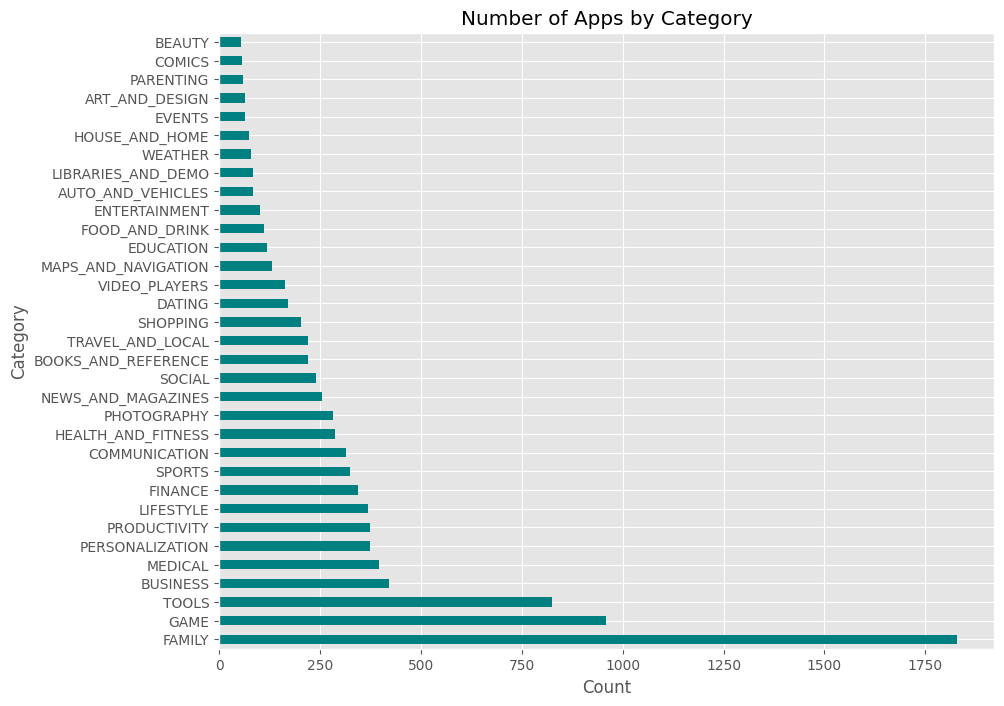

In [41]:
plt.figure(figsize=(10,8))
apps['Category'].value_counts().plot(kind='barh', color='teal')
plt.title('Number of Apps by Category')
plt.xlabel('Count')
plt.show()

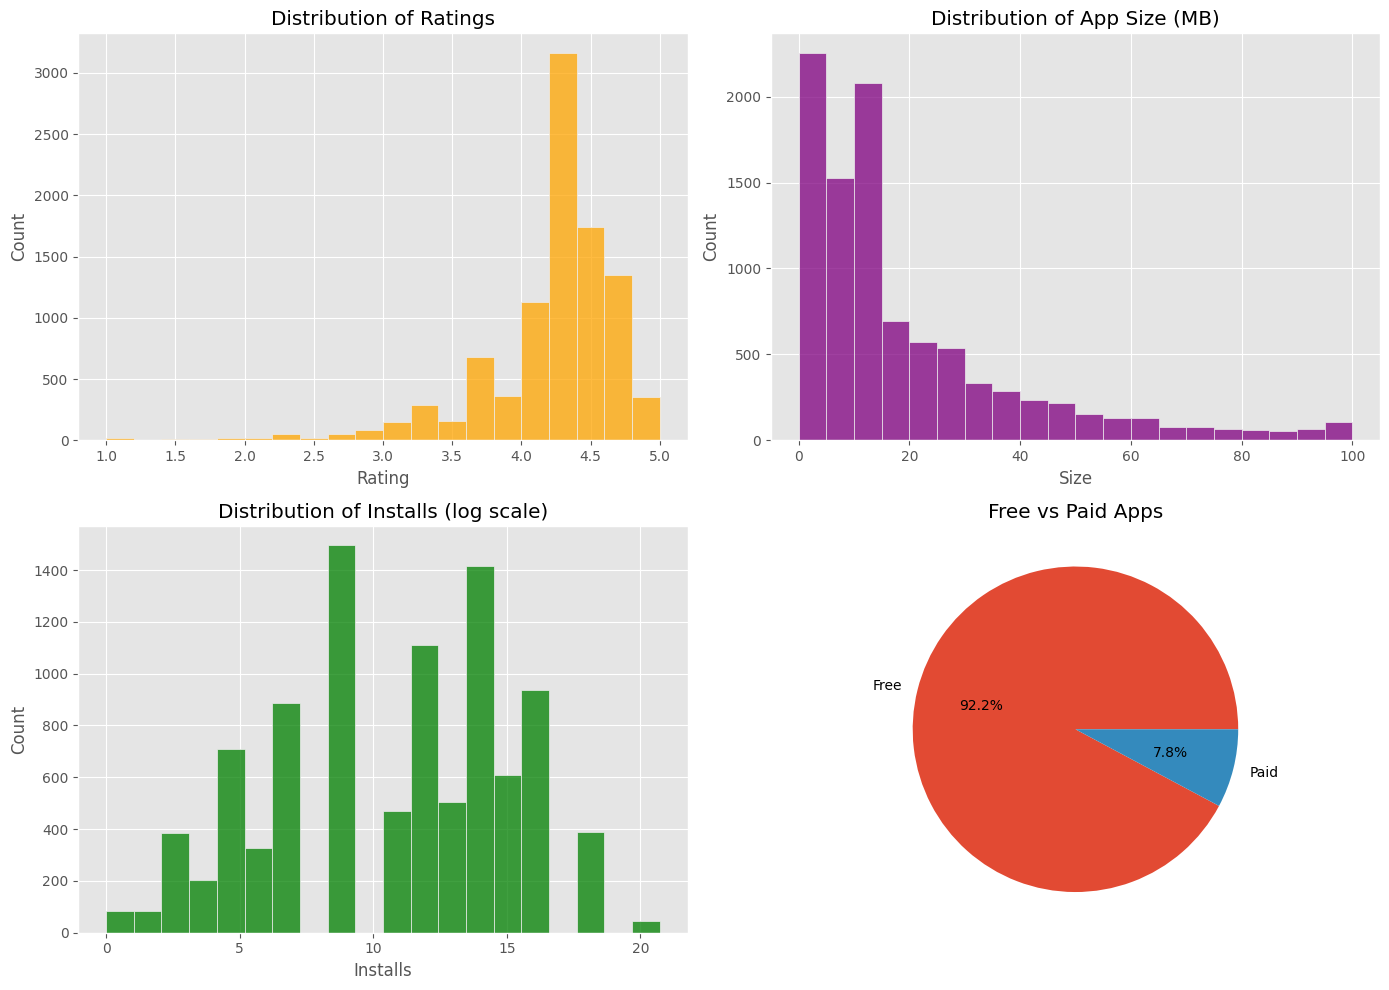

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.histplot(apps['Rating'], bins=20, ax=axes[0,0], color='orange')
axes[0,0].set_title('Distribution of Ratings')

sns.histplot(apps['Size'], bins=20, ax=axes[0,1], color='purple')
axes[0,1].set_title('Distribution of App Size (MB)')

sns.histplot(np.log1p(apps['Installs']), bins=20, ax=axes[1,0], color='green')
axes[1,0].set_title('Distribution of Installs (log scale)')

apps['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1,1])
axes[1,1].set_title('Free vs Paid Apps')

plt.tight_layout()
plt.show()

In [43]:
top_categories = apps.groupby('Category').agg(
    avg_rating=('Rating', 'mean'),
    avg_installs=('Installs', 'mean'),
    app_count=('App', 'count')
).sort_values('avg_installs', ascending=False).head(10)

top_categories

,avg_rating,avg_installs,app_count
Category,,,
COMMUNICATION,4.154921,3.504215e+07,315
VIDEO_PLAYERS,4.068098,2.409143e+07,163
SOCIAL,4.255230,2.296179e+07,239
ENTERTAINMENT,4.135294,2.072216e+07,102
PHOTOGRAPHY,4.166548,1.654501e+07,281
PRODUCTIVITY,4.206150,1.548955e+07,374
GAME,4.249948,1.447229e+07,959
TRAVEL_AND_LOCAL,4.103196,1.321866e+07,219
TOOLS,4.073455,9.698511e+06,825


In [44]:
sentiment_summary = reviews.groupby('App')['Sentiment_Polarity'].mean().reset_index()
sentiment_summary.columns = ['App', 'Avg_Sentiment_Polarity']
sentiment_summary.head()

,App,Avg_Sentiment_Polarity
0,10 Best Foods for You,0.470733
1,104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,0.392405
2,11st,0.181294
3,1800 Contacts - Lens Store,0.318145
4,1LINE – One Line with One Touch,0.196290


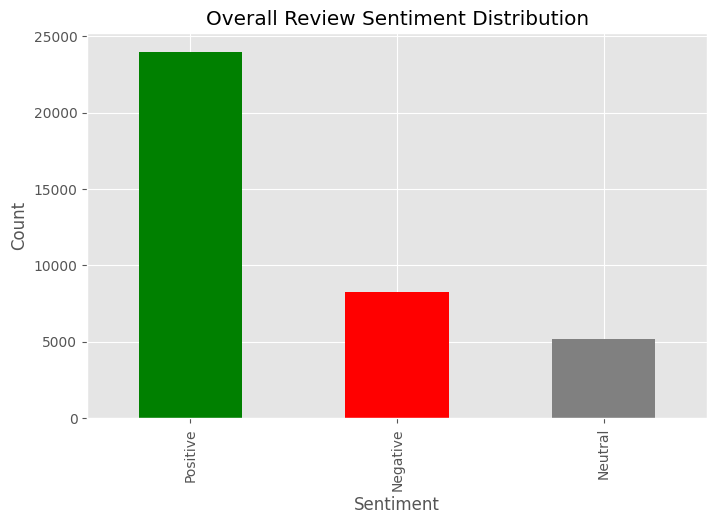

In [45]:
plt.figure(figsize=(8,5))
reviews['Sentiment'].value_counts().plot(kind='bar', color=['green','red','gray'])
plt.title('Overall Review Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

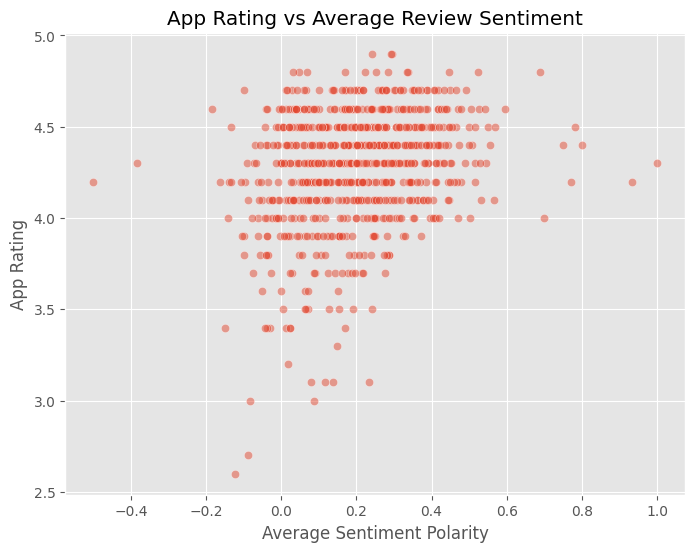

In [46]:
merged = apps.merge(sentiment_summary, on='App', how='inner')
plt.figure(figsize=(8,6))
sns.scatterplot(data=merged, x='Avg_Sentiment_Polarity', y='Rating', alpha=0.5)
plt.title('App Rating vs Average Review Sentiment')
plt.xlabel('Average Sentiment Polarity')
plt.ylabel('App Rating')
plt.show()

## Key Insights

1. FAMILY (1,832 apps) and GAME (959 apps) are the most saturated categories on the Play Store, while BEAUTY, COMICS, and PARENTING have the fewest apps.
2. COMMUNICATION apps have the highest average installs (35M+) despite not being the most numerous category, suggesting strong demand per app in this space.
3. Most apps are Free rather than Paid, and the majority maintain ratings between 4.0 and 4.5.
4. App sizes and install counts vary widely — most apps are under 30MB, while install counts span from a few thousand to over 100 million.
5. The majority of user reviews (around 64%) are positive, with only about 22% negative and 14% neutral.
6. There is a mild positive relationship between average review sentiment and app rating, though most apps maintain high ratings (4.0+) regardless of sentiment polarity.

## Recommendations

1. New developers should consider less saturated categories (like Beauty, Comics, or Parenting) to face less competition.
2. Apps in the Communication category show strong install potential and may be a good benchmark for engagement strategies.
3. Since most apps are free, monetization strategies should focus on in-app purchases or ads rather than upfront pricing.
4. Developers should actively monitor user sentiment in reviews, as it shows some correlation with overall app ratings.

## Conclusion
This analysis of the Google Play Store dataset reveals clear patterns in category saturation, install popularity, and user sentiment. Communication and Gaming apps drive the highest engagement, while overall user sentiment toward apps remains largely positive, reflecting a generally satisfied user base across the platform.